# Newsgroups20: Experimentos de Topic Extraction

Este notebook compara extraccion de topicos sobre el subset tecnico de 8 categorias de 20 Newsgroups usando cuatro configuraciones:

1. TF-IDF + NMF (Frobenius)
2. BoW + NMF (KL divergence)
3. Nomic embeddings + NMF (Frobenius)
4. Qwen3 embeddings + NMF (Frobenius)

La comparativa incluye:
- Cuantitativa: NMI, ARI, confianza media, entropia de asignacion y error de reconstruccion.
- Cualitativa: terminos por topico (cuando aplica), documentos representativos y distribucion de etiquetas por topico.

In [26]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import NMF
from sklearn.feature_extraction import text as sklearn_text
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_colwidth", 200)

In [15]:
# Resolver root del repo y rutas de entrada/salida
CANDIDATE_ROOT = Path.cwd().resolve()
if CANDIDATE_ROOT.name == "notebooks" and CANDIDATE_ROOT.parent.name == "validation":
    ROOT = CANDIDATE_ROOT.parent.parent
else:
    ROOT = next(
        (p for p in [CANDIDATE_ROOT, *CANDIDATE_ROOT.parents] if (p / "validation").exists()),
        CANDIDATE_ROOT,
    )

EDA_TABLES = ROOT / "validation" / "results" / "newsgroups20_eda" / "tables"
UMAP_ROOT = ROOT / "validation" / "results" / "newsgroups20_umap"
CACHE_DIR = UMAP_ROOT / "cache"

RESULTS_DIR = ROOT / "validation" / "results" / "newsgroups20_topic_extraction"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
for p in [RESULTS_DIR, TABLES_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

subset_path = EDA_TABLES / "newsgroups20_topic8_subset.csv"
if not subset_path.exists():
    raise FileNotFoundError(f"No se encontro el subset: {subset_path}")

print(f"ROOT: {ROOT}")
print(f"Subset: {subset_path}")
print(f"Cache embeddings: {CACHE_DIR}")
print(f"Resultados: {RESULTS_DIR}")

ROOT: /home/gabriel/clase/TFG/TFG-Chatbot
Subset: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/newsgroups20_eda/tables/newsgroups20_topic8_subset.csv
Cache embeddings: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/newsgroups20_umap/cache
Resultados: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/newsgroups20_topic_extraction


In [20]:
# Carga del dataset
df = pd.read_csv(subset_path)
if "text" not in df.columns:
    if "document" in df.columns:
        df = df.rename(columns={"document": "text"})
    else:
        raise ValueError("El dataset no contiene columna 'text' ni 'document'.")

df["text"] = df["text"].astype(str).str.strip()
df["label"] = df["label"].astype(str)
df = df[df["text"].str.len() > 0].drop_duplicates(subset=["text"]).reset_index(drop=True)

def clean_newsgroup_text(raw: str) -> str:
    # Filtra lineas con baja proporcion alfabetica (tipico de bloques codificados/ruido).
    kept_lines = []
    for line in raw.splitlines():
        s = line.strip()
        if not s:
            continue
        alpha = sum(ch.isalpha() for ch in s)
        alnum = sum(ch.isalnum() for ch in s)
        if alnum > 0 and (alpha / alnum) < 0.55:
            continue
        kept_lines.append(s)

    text = " ".join(kept_lines)
    text = re.sub(r"https?://\S+|www\.\S+|\S+@\S+", " ", text)
    text = re.sub(r"[_`~^|\\/=+*#<>$%&{}\[\]\(\)-]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    # Mantiene alineacion con embeddings cacheados aunque el texto quede casi vacio.
    return text if text else "emptydoc"

df["text_clean"] = df["text"].map(clean_newsgroup_text)

texts = df["text"].tolist()
texts_clean = df["text_clean"].tolist()
labels = df["label"].tolist()
label_codes = pd.Categorical(labels).codes

print(f"Documentos: {len(df)}")
print(f"Etiquetas unicas: {df['label'].nunique()}")
print("Ejemplo de limpieza (original -> clean):")
print(df.loc[0, "text"][:180])
print("---")
print(df.loc[0, "text_clean"][:180])
display(df.head(3))

Documentos: 7614
Etiquetas unicas: 8
Ejemplo de limpieza (original -> clean):
A fair number of brave souls who upgraded their SI clock oscillator have
shared their experiences for this poll. Please send a brief message detailing
your experiences with the pro
---
a fair number of brave souls who upgraded their si clock oscillator have shared their experiences for this poll. please send a brief message detailing your experiences with the pro


,text,label_id,label,char_len,tok_len,text_clean
0,A fair number of brave souls who upgraded their SI clock oscillator have\nshared their experiences for this poll. Please send a brief message detailing\nyour experiences with the procedure. Top sp...,4,comp.sys.mac.hardware,530,92,a fair number of brave souls who upgraded their si clock oscillator have shared their experiences for this poll. please send a brief message detailing your experiences with the procedure. top spee...
1,"well folks, my mac plus finally gave up the ghost this weekend after\nstarting life as a 512k way back in 1985. sooo, i'm in the market for a\nnew machine a bit sooner than i intended to be...\n\...",4,comp.sys.mac.hardware,1659,310,"well folks, my mac plus finally gave up the ghost this weekend after starting life as a 512k way back in 1985. sooo, i'm in the market for a new machine a bit sooner than i intended to be... i'm l..."
2,Do you have Weitek's address/phone number? I'd like to get some information\nabout this chip.,1,comp.graphics,93,18,do you have weitek's address phone number? i'd like to get some information about this chip.


In [28]:
# Construccion de matrices textuales sobre texto limpio
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    token_pattern=r"(?u)\b[a-z][a-z]{2,}\b",
    max_features=7000,
    ngram_range=(1, 2),
    min_df=4,
    max_df=0.85,
    sublinear_tf=True,
    strip_accents="unicode",
)

# Stopwords extra detectadas en tokens ruidosos del subset tecnico.
extra_noise_stopwords = {"max", "bhj", "bxn", "chz", "giz", "qax", "biz"}
bow_stop_words = sorted(sklearn_text.ENGLISH_STOP_WORDS.union(extra_noise_stopwords))

bow_vectorizer = CountVectorizer(
    stop_words=bow_stop_words,
    token_pattern=r"(?u)\b[a-z][a-z]{2,}\b",
    max_features=7000,
    ngram_range=(1, 1),
    min_df=4,
    max_df=0.85,
    strip_accents="unicode",
)

X_tfidf = tfidf_vectorizer.fit_transform(texts_clean)
X_bow = bow_vectorizer.fit_transform(texts_clean)

print(f"TF-IDF shape: {X_tfidf.shape}")
print(f"BoW shape: {X_bow.shape}")
print("Top 20 terminos BoW tras limpieza:")
bow_freq = np.asarray(X_bow.sum(axis=0)).ravel()
top_idx = np.argsort(bow_freq)[::-1][:20]
print(bow_vectorizer.get_feature_names_out()[top_idx].tolist())

TF-IDF shape: (7614, 7000)
BoW shape: (7614, 7000)
Top 20 terminos BoW tras limpieza:
['use', 'like', 'file', 'just', 'know', 'don', 'windows', 'does', 'time', 'data', 'program', 'using', 'space', 'used', 'available', 'software', 'new', 'need', 'problem', 'image']


In [22]:
# Carga de embeddings cacheados (sin recomputar Ollama)
nomic_cache = CACHE_DIR / f"nomic_embeddings_n{len(df)}.npy"
qwen_cache = CACHE_DIR / f"qwen3_embeddings_n{len(df)}.npy"

if not nomic_cache.exists() or not qwen_cache.exists():
    raise FileNotFoundError(
        "No se encontraron embeddings cacheados para el mismo numero de filas del subset. "
        f"Esperados: {nomic_cache} y {qwen_cache}"
    )

X_nomic_raw = np.load(nomic_cache)
X_qwen_raw = np.load(qwen_cache)

if X_nomic_raw.shape[0] != len(df) or X_qwen_raw.shape[0] != len(df):
    raise ValueError(
        f"Mismatch de filas. df={len(df)}, nomic={X_nomic_raw.shape[0]}, qwen={X_qwen_raw.shape[0]}"
    )

# NMF requiere no negatividad: escalamos cada embedding a [0,1] por feature
nomic_scaler = MinMaxScaler()
qwen_scaler = MinMaxScaler()
X_nomic = nomic_scaler.fit_transform(X_nomic_raw).astype(np.float32)
X_qwen = qwen_scaler.fit_transform(X_qwen_raw).astype(np.float32)

print(f"Nomic raw/nonneg: {X_nomic_raw.shape} -> {X_nomic.shape}")
print(f"Qwen raw/nonneg: {X_qwen_raw.shape} -> {X_qwen.shape}")
print(f"Nomic min/max after scaling: {X_nomic.min():.3f}/{X_nomic.max():.3f}")
print(f"Qwen min/max after scaling: {X_qwen.min():.3f}/{X_qwen.max():.3f}")

Nomic raw/nonneg: (7614, 768) -> (7614, 768)
Qwen raw/nonneg: (7614, 1024) -> (7614, 1024)
Nomic min/max after scaling: 0.000/1.000
Qwen min/max after scaling: 0.000/1.000


## Definicion de utilidades de evaluacion

In [6]:
def dominant_topic_distribution(W: np.ndarray) -> pd.Series:
    dominant = W.argmax(axis=1)
    return pd.Series(dominant).value_counts(normalize=True).sort_index()


def normalized_entropy(probs: np.ndarray) -> float:
    probs = probs[probs > 0]
    if probs.size == 0:
        return 0.0
    h = -np.sum(probs * np.log(probs))
    h_max = np.log(len(probs))
    return float(h / h_max) if h_max > 0 else 0.0


def topic_diversity(terms_per_topic: list[list[str]]) -> float:
    flat = [t for topic in terms_per_topic for t in topic]
    if not flat:
        return np.nan
    return float(len(set(flat)) / len(flat))


def term_coherence_umass(X_counts, topics_idx: list[np.ndarray], eps: float = 1.0) -> float:
    # Coherencia aproximada tipo UMass sobre matriz de coocurrencia binaria
    X_bin = (X_counts > 0).astype(int).tocsr()
    df_term = np.asarray(X_bin.sum(axis=0)).ravel()
    cooc = (X_bin.T @ X_bin).toarray()

    topic_scores = []
    for idx in topics_idx:
        pairs = 0
        score = 0.0
        for i in range(1, len(idx)):
            wi = idx[i]
            for j in range(i):
                wj = idx[j]
                pairs += 1
                score += np.log((cooc[wi, wj] + eps) / max(df_term[wj], 1))
        if pairs > 0:
            topic_scores.append(score / pairs)
    if not topic_scores:
        return np.nan
    return float(np.mean(topic_scores))


def get_top_terms(H: np.ndarray, feature_names: np.ndarray, top_n: int = 10) -> tuple[list[list[str]], list[np.ndarray]]:
    topics_terms = []
    topics_idx = []
    for comp in H:
        idx = np.argsort(comp)[::-1][:top_n]
        topics_idx.append(idx)
        topics_terms.append(feature_names[idx].tolist())
    return topics_terms, topics_idx

## Ejecucion de experimentos

In [29]:
k_values = [6, 8, 10, 12]
random_state = 42

configs: list[dict[str, Any]] = [
    {
        "name": "tfidf_nmf_fro",
        "X": X_tfidf,
        "alpha": 0.0,
        "l1_ratio": 0.0,
        "solver": "cd",
        "beta_loss": "frobenius",
        "feature_names": np.array(tfidf_vectorizer.get_feature_names_out()),
        "counts_for_coherence": X_bow,
    },
    {
        "name": "bow_nmf_kl",
        "X": X_bow,
        "alpha": 0.0,
        "l1_ratio": 0.0,
        "solver": "mu",
        "beta_loss": "kullback-leibler",
        "feature_names": np.array(bow_vectorizer.get_feature_names_out()),
        "counts_for_coherence": X_bow,
    },
    {
        "name": "nomic_nmf_fro",
        "X": X_nomic,
        "alpha": 0.0,
        "l1_ratio": 0.0,
        "solver": "cd",
        "beta_loss": "frobenius",
        "feature_names": None,
        "counts_for_coherence": None,
    },
    {
        "name": "qwen3_nmf_fro",
        "X": X_qwen,
        "alpha": 0.0,
        "l1_ratio": 0.0,
        "solver": "cd",
        "beta_loss": "frobenius",
        "feature_names": None,
        "counts_for_coherence": None,
    },
]

rows = []
topic_terms_records = []
doc_assignments = []

for cfg in configs:
    for k in k_values:
        model = NMF(
            n_components=k,
            init="nndsvda",
            random_state=random_state,
            max_iter=800,
            solver=cfg["solver"],
            beta_loss=cfg["beta_loss"],
            alpha_W=cfg["alpha"],
            alpha_H=cfg["alpha"],
            l1_ratio=cfg["l1_ratio"],
        )

        W = model.fit_transform(cfg["X"])
        H = model.components_
        dominant_topic = W.argmax(axis=1)

        topic_mass = dominant_topic_distribution(W)
        topic_entropy = normalized_entropy(topic_mass.values)
        confidence = float(np.mean(W.max(axis=1) / np.clip(W.sum(axis=1), 1e-12, None)))

        row = {
            "model": cfg["name"],
            "k": k,
            "nmi": float(normalized_mutual_info_score(label_codes, dominant_topic)),
            "ari": float(adjusted_rand_score(label_codes, dominant_topic)),
            "topic_entropy": topic_entropy,
            "avg_topic_confidence": confidence,
            "reconstruction_err": float(model.reconstruction_err_),
            "n_iter": int(model.n_iter_),
        }

        if cfg["feature_names"] is not None:
            terms_per_topic, topic_idx = get_top_terms(H, cfg["feature_names"], top_n=12)
            row["topic_diversity"] = topic_diversity(terms_per_topic)
            row["coherence_umass"] = term_coherence_umass(cfg["counts_for_coherence"], topic_idx)

            for t_id, terms in enumerate(terms_per_topic):
                topic_terms_records.append(
                    {
                        "model": cfg["name"],
                        "k": k,
                        "topic": t_id,
                        "top_terms": ", ".join(terms),
                    }
                )
        else:
            row["topic_diversity"] = np.nan
            row["coherence_umass"] = np.nan

        rows.append(row)

        for i in range(len(df)):
            doc_assignments.append(
                {
                    "model": cfg["name"],
                    "k": k,
                    "doc_idx": i,
                    "label": labels[i],
                    "topic": int(dominant_topic[i]),
                    "topic_weight": float(W[i, dominant_topic[i]]),
                    "text": texts[i],
                }
            )

results_df = pd.DataFrame(rows).sort_values(["model", "k"]).reset_index(drop=True)
assign_df = pd.DataFrame(doc_assignments)
terms_df = pd.DataFrame(topic_terms_records)

results_df.to_csv(TABLES_DIR / "topic_extraction_metrics.csv", index=False, encoding="utf-8")
assign_df.to_csv(TABLES_DIR / "topic_assignments_all_models.csv", index=False, encoding="utf-8")
if not terms_df.empty:
    terms_df.to_csv(TABLES_DIR / "topic_terms_text_models.csv", index=False, encoding="utf-8")

display(results_df)
print(f"Metricas guardadas en {TABLES_DIR / 'topic_extraction_metrics.csv'}")

/home/gabriel/clase/TFG/TFG-Chatbot/.venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 800 reached. Increase it to improve convergence.
  warnings.warn(


,model,k,nmi,ari,topic_entropy,avg_topic_confidence,reconstruction_err,n_iter,topic_diversity,coherence_umass
0,bow_nmf_kl,6,0.302498,0.194532,0.908415,0.674555,1738.179939,100,0.902778,-1.707958
1,bow_nmf_kl,8,0.383659,0.293645,0.925281,0.662465,1703.582930,80,0.875000,-1.682031
2,bow_nmf_kl,10,0.383984,0.285411,0.935950,0.621140,1682.616292,90,0.866667,-1.852389
3,bow_nmf_kl,12,0.360736,0.254850,0.946760,0.590213,1665.697537,120,0.875000,-1.818909
4,nomic_nmf_fro,6,0.163085,0.082751,0.893299,0.345300,295.671875,494,NaN,NaN
5,nomic_nmf_fro,8,0.166042,0.098653,0.873369,0.306330,288.876129,519,NaN,NaN
6,nomic_nmf_fro,10,0.101438,0.046026,0.885983,0.268856,283.337067,603,NaN,NaN
7,nomic_nmf_fro,12,0.171630,0.112075,0.795052,0.261658,278.657501,721,NaN,NaN
8,qwen3_nmf_fro,6,0.269700,0.181110,0.885877,0.333042,350.876373,800,NaN,NaN
9,qwen3_nmf_fro,8,0.290735,0.214279,0.944865,0.291839,344.615051,511,NaN,NaN


Metricas guardadas en /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/newsgroups20_topic_extraction/tables/topic_extraction_metrics.csv


In [30]:
# Resumen del mejor k por modelo segun NMI
best_by_model = results_df.sort_values(["model", "nmi"], ascending=[True, False]).groupby("model", as_index=False).first()
best_by_model.to_csv(TABLES_DIR / "topic_extraction_best_by_model.csv", index=False, encoding="utf-8")
display(best_by_model)

,model,k,nmi,ari,topic_entropy,avg_topic_confidence,reconstruction_err,n_iter,topic_diversity,coherence_umass
0,bow_nmf_kl,10,0.383984,0.285411,0.935950,0.621140,1682.616292,90,0.866667,-1.852389
1,nomic_nmf_fro,12,0.171630,0.112075,0.795052,0.261658,278.657501,721,NaN,NaN
2,qwen3_nmf_fro,8,0.290735,0.214279,0.944865,0.291839,344.615051,511,NaN,NaN
3,tfidf_nmf_fro,10,0.269462,0.177661,0.947953,0.538717,85.120089,118,0.941667,-2.644930


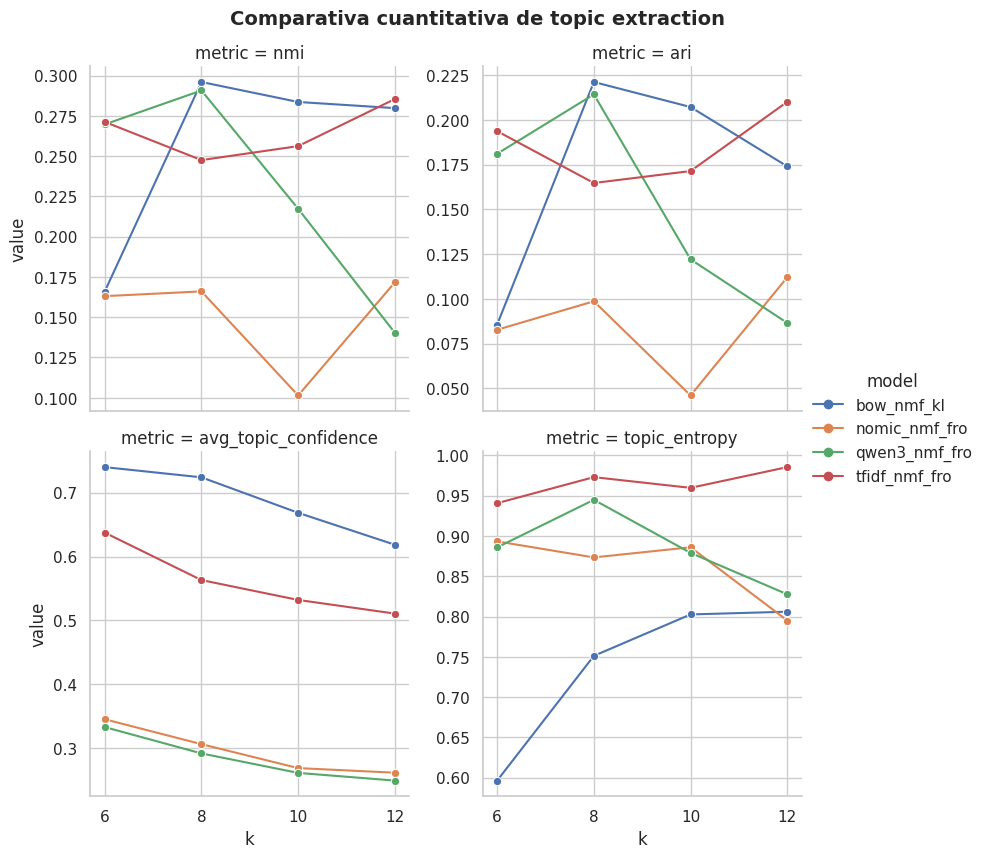

In [9]:
# Visualizacion cuantitativa principal (NMI y ARI)
plot_df = results_df.melt(
    id_vars=["model", "k"],
    value_vars=["nmi", "ari", "avg_topic_confidence", "topic_entropy"],
    var_name="metric",
    value_name="value",
)

g = sns.relplot(
    data=plot_df,
    x="k",
    y="value",
    hue="model",
    col="metric",
    kind="line",
    marker="o",
    col_wrap=2,
    height=4.2,
    facet_kws={"sharey": False},
)
g.fig.suptitle("Comparativa cuantitativa de topic extraction", y=1.02, fontsize=14, fontweight="bold")
g.savefig(FIGURES_DIR / "topic_extraction_metrics_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

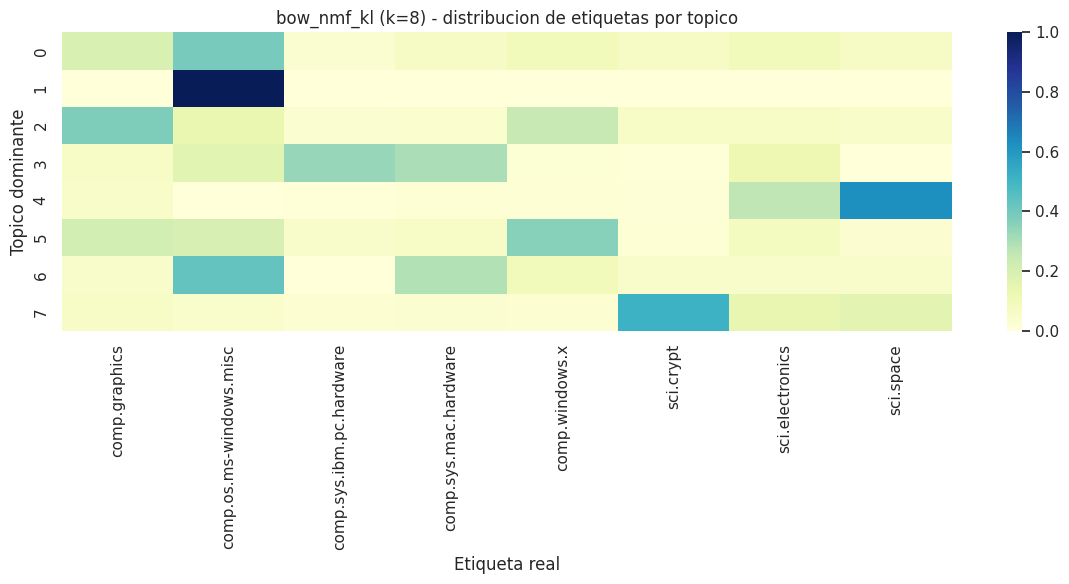

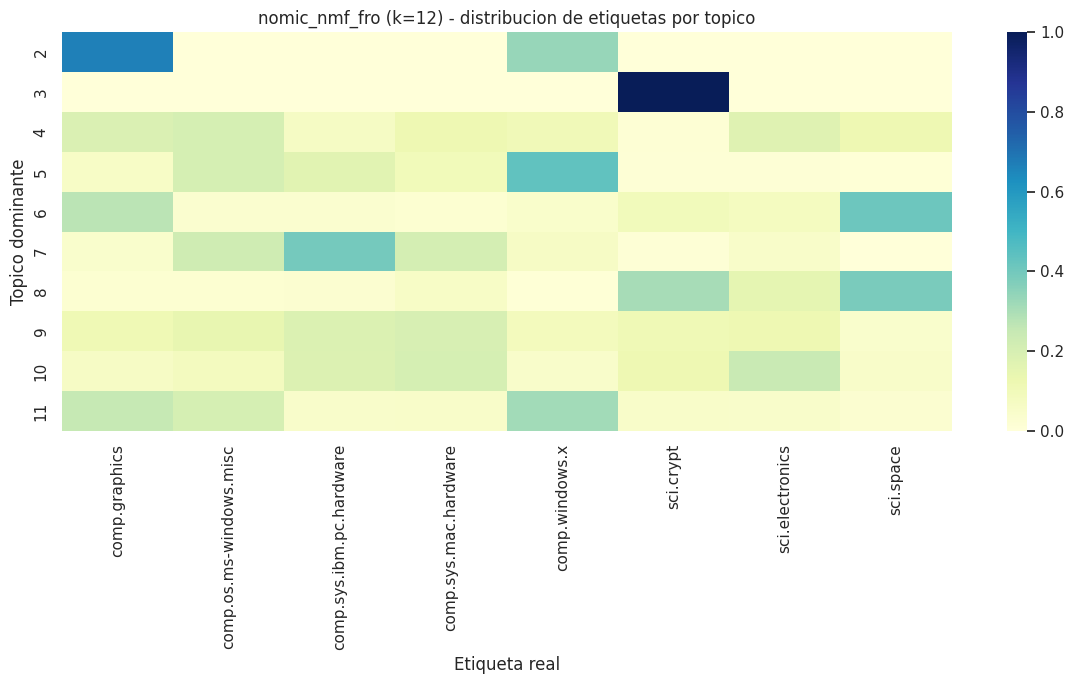

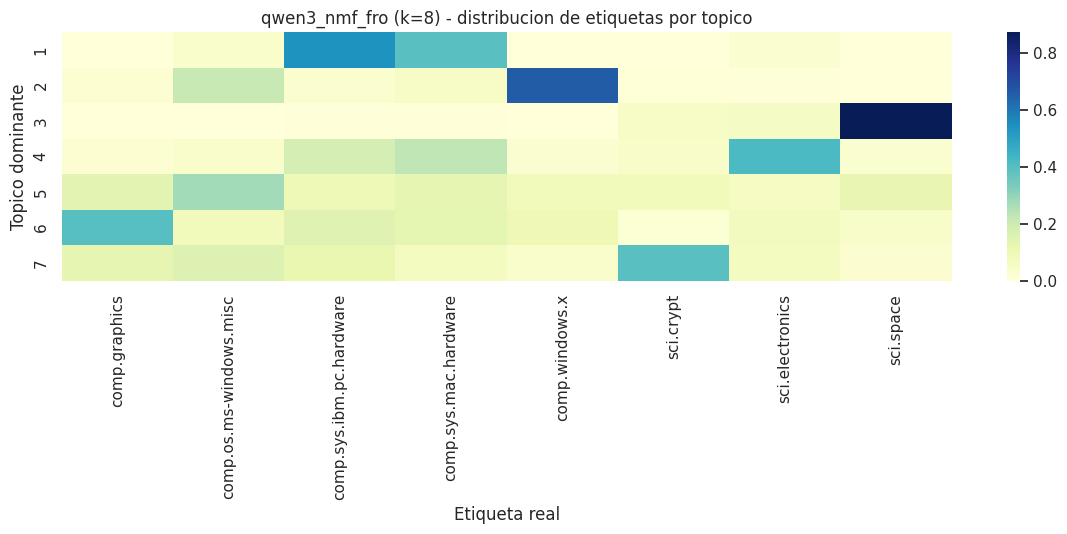

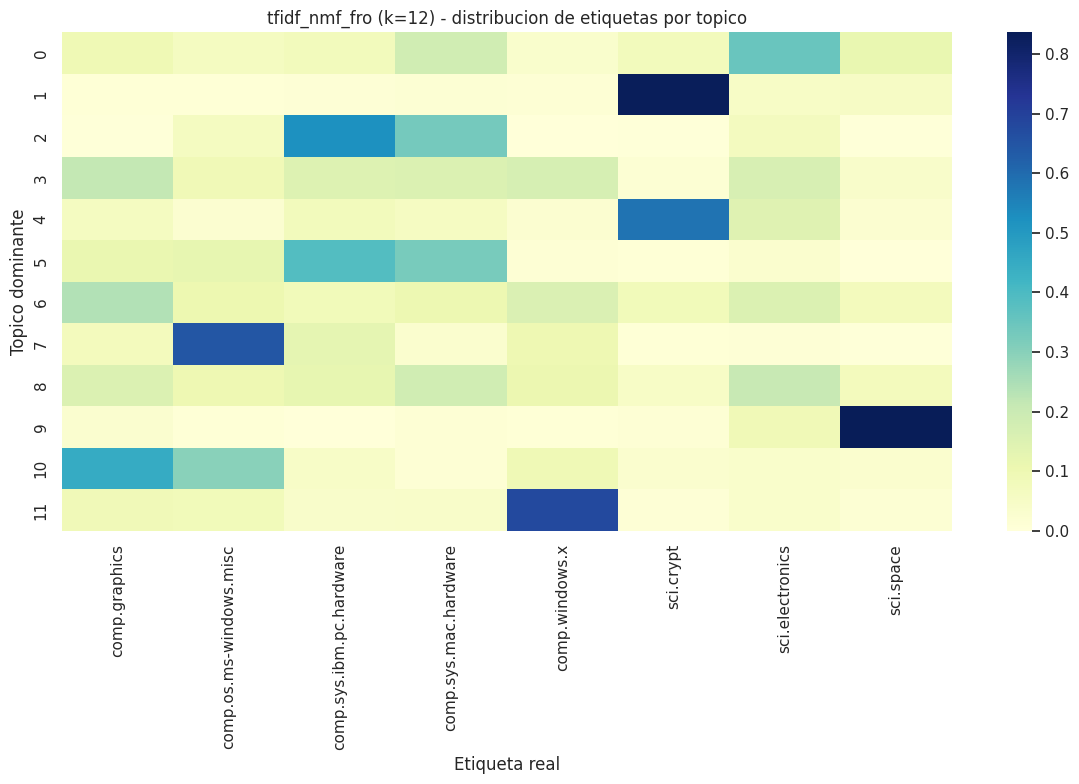

In [10]:
# Heatmaps modelo-topico-etiqueta para el mejor k de cada modelo
for _, row in best_by_model.iterrows():
    model_name = row["model"]
    best_k = int(row["k"])
    slice_df = assign_df[(assign_df["model"] == model_name) & (assign_df["k"] == best_k)].copy()

    ctab = pd.crosstab(slice_df["topic"], slice_df["label"], normalize="index")
    ctab.to_csv(TABLES_DIR / f"topic_label_distribution_{model_name}_k{best_k}.csv", encoding="utf-8")

    fig, ax = plt.subplots(figsize=(12, max(4, 0.5 * ctab.shape[0] + 2)))
    sns.heatmap(ctab, cmap="YlGnBu", ax=ax)
    ax.set_title(f"{model_name} (k={best_k}) - distribucion de etiquetas por topico")
    ax.set_xlabel("Etiqueta real")
    ax.set_ylabel("Topico dominante")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"topic_label_heatmap_{model_name}_k{best_k}.png", dpi=180, bbox_inches="tight")
    plt.show()

## Validacion cualitativa

In [31]:
# Topicos con terminos (solo modelos textuales)
if terms_df.empty:
    print("No hay modelos con terminos interpretables.")
else:
    for _, row in best_by_model.iterrows():
        model_name = row["model"]
        best_k = int(row["k"])
        subset_terms = terms_df[(terms_df["model"] == model_name) & (terms_df["k"] == best_k)]
        if subset_terms.empty:
            continue
        print("=" * 90)
        print(f"Modelo: {model_name} | k={best_k} | top terms por topico")
        print("=" * 90)
        display(subset_terms[["topic", "top_terms"]].sort_values("topic"))

Modelo: bow_nmf_kl | k=10 | top terms por topico


,topic,top_terms
50,0,"ftp, file, edu, available, jpeg, pub, files, mail, graphics, format, image, version"
51,1,"windows, dos, driver, file, mouse, drivers, microsoft, use, files, win, using, printer"
52,2,"window, server, use, motif, widget, application, display, set, sun, using, file, lib"
53,3,"file, output, program, entry, build, info, line, check, section, int, char, rules"
54,4,"just, like, don, know, think, good, want, time, people, does, really, problem"
55,5,"key, government, encryption, chip, clipper, use, keys, security, law, privacy, public, people"
56,6,"space, nasa, earth, launch, orbit, shuttle, moon, mission, solar, satellite, spacecraft, lunar"
57,7,"drive, card, scsi, mac, disk, does, apple, bus, bit, monitor, use, hard"
58,8,"power, use, used, ground, wire, circuit, current, radio, supply, light, heat, battery"
59,9,"image, data, graphics, software, bit, color, images, code, processing, computer, using, display"


Modelo: tfidf_nmf_fro | k=10 | top terms por topico


,topic,top_terms
14,0,"window, problem, server, using, display, application, set, use, motif, running, manager, screen"
15,1,"just, don, like, think, good, want, use, really, people, sure, time, right"
16,2,"drive, scsi, hard, drives, disk, ide, controller, hard drive, floppy, mac, boot, hard disk"
17,3,"thanks, advance, thanks advance, mail, looking, help, information, mail thanks, email, appreciated, info, hello"
18,4,"card, video, bus, monitor, cards, video card, drivers, isa, driver, local bus, vga, board"
19,5,"key, chip, clipper, encryption, government, keys, escrow, algorithm, phone, law, clipper chip, nsa"
20,6,"ftp, file, files, edu, format, zip, available, pub, gif, directory, site, graphics"
21,7,"does, know, does know, anybody, does anybody, anybody know, don know, let know, program, let, know ftp, chips"
22,8,"windows, dos, run, running, file, microsoft, driver, version, win, dos windows, using, drivers"
23,9,"space, nasa, shuttle, orbit, earth, launch, moon, information, science, mission, research, data"


In [12]:
# Documentos representativos por topico (todos los modelos)
qual_records = []

for _, row in best_by_model.iterrows():
    model_name = row["model"]
    best_k = int(row["k"])

    sub = assign_df[(assign_df["model"] == model_name) & (assign_df["k"] == best_k)].copy()

    for topic_id, topic_df in sub.groupby("topic"):
        label_mix = topic_df["label"].value_counts(normalize=True).head(3)
        label_mix_txt = " | ".join([f"{lab}:{pct:.2f}" for lab, pct in label_mix.items()])

        reps = topic_df.sort_values("topic_weight", ascending=False).head(3)
        for rank, (_, rep) in enumerate(reps.iterrows(), start=1):
            qual_records.append(
                {
                    "model": model_name,
                    "k": best_k,
                    "topic": int(topic_id),
                    "rank_in_topic": rank,
                    "topic_weight": float(rep["topic_weight"]),
                    "label": rep["label"],
                    "top3_label_mix": label_mix_txt,
                    "text": rep["text"],
                }
            )

qual_df = pd.DataFrame(qual_records).sort_values(["model", "topic", "rank_in_topic"])
qual_df.to_csv(TABLES_DIR / "topic_qualitative_examples.csv", index=False, encoding="utf-8")
display(qual_df.head(40))
print(f"Ejemplos cualitativos guardados en {TABLES_DIR / 'topic_qualitative_examples.csv'}")

,model,k,topic,rank_in_topic,topic_weight,label,top3_label_mix,text
0,bow_nmf_kl,8,0,1,68.319945,comp.os.ms-windows.misc,comp.os.ms-windows.misc:0.39 | comp.graphics:0.19 | comp.windows.x:0.10,------------ Part 12 of 14 ------------\nMAX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'\nMAX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'\nMAX>'AX>'AX>'AX>'AX>'AX>'AX>'...
1,bow_nmf_kl,8,0,2,62.530760,comp.os.ms-windows.misc,comp.os.ms-windows.misc:0.39 | comp.graphics:0.19 | comp.windows.x:0.10,"------------ Part 13 of 14 ------------\nMTM(]/3V9F0->7EY>7EZ[N[LJ*GK?W]]'1T>EI:6EI:6E1T='1Z4+I:5'1Z4+\nM""V;$Q#&'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'\nMAX>'AX>'AX>'AX>'AX>'AX>'AX>'..."
2,bow_nmf_kl,8,0,3,60.564134,comp.os.ms-windows.misc,comp.os.ms-windows.misc:0.39 | comp.graphics:0.19 | comp.windows.x:0.10,"------------ Part 11 of 14 ------------\nMR1865%22DM75U=75U4)""0IV=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=\nMG9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=G9V=\nMG9V=G9V=G9V=G9V=G9V=G9V=G9V=..."
3,bow_nmf_kl,8,1,1,20.684673,comp.os.ms-windows.misc,comp.os.ms-windows.misc:1.00,"------------ Part 10 of 14 ------------\nM:J""U$$,^UM[>WE/M[>V+BXN+BXN+BXN+BXOM[>U34U-34[""PL!D9<7'2TM+2\nM/3T]/3T]F9F9`P,#7EY>NRIZWT='I0MFQ#&'AX>'AX>'AX>'AX>'AX>'AX>'\nMAX>'AX>'AX>'AX>'AX>'AX>'AX>'..."
4,bow_nmf_kl,8,2,1,12.178378,comp.graphics,comp.graphics:0.38 | comp.windows.x:0.25 | comp.os.ms-windows.misc:0.14,Archive-name: graphics/resources-list/part1\nLast-modified: 1993/04/27\n\n\nComputer Graphics Resource Listing : WEEKLY POSTING [ PART 1/3 ]\n===================================================\nL...
5,bow_nmf_kl,8,2,2,12.033475,comp.graphics,comp.graphics:0.38 | comp.windows.x:0.25 | comp.os.ms-windows.misc:0.14,Archive-name: graphics/resources-list/part1\nLast-modified: 1993/04/17\n\n\nComputer Graphics Resource Listing : WEEKLY POSTING [ PART 1/3 ]\n===================================================\nL...
6,bow_nmf_kl,8,2,3,9.217976,comp.windows.x,comp.graphics:0.38 | comp.windows.x:0.25 | comp.os.ms-windows.misc:0.14,Archive-name: x-faq/part3\nLast-modified: 1993/04/04\n\n----------------------------------------------------------------------\nSubject: 58)! Where can I get patches to X11R5?\n\n\tThe release of...
7,bow_nmf_kl,8,3,1,12.098515,comp.windows.x,comp.sys.ibm.pc.hardware:0.33 | comp.sys.mac.hardware:0.30 | comp.os.ms-windows.misc:0.16,"Here's a listing that I came accross a while ago. This question seems to \ncome up often enough that I figured this would be of interest. Note that \nthe server ""X Appeal"" for DOS is available i..."
8,bow_nmf_kl,8,3,2,9.665166,comp.sys.mac.hardware,comp.sys.ibm.pc.hardware:0.33 | comp.sys.mac.hardware:0.30 | comp.os.ms-windows.misc:0.16,{Send follow ups to comp.sys.mac.advocacy. Sorry about the header but the \nPnews here does not let one easily change the headers and I gave up after a \nyear of trying. This sheet is also availab...
9,bow_nmf_kl,8,3,3,7.286838,sci.electronics,comp.sys.ibm.pc.hardware:0.33 | comp.sys.mac.hardware:0.30 | comp.os.ms-windows.misc:0.16,"Since electrical wiring questions do turn up from time to time on\nsci.electronics (and the answers aren't always apparent, even to those skilled\nin electronics), I am hijacking the following FAQ..."


Ejemplos cualitativos guardados en /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/newsgroups20_topic_extraction/tables/topic_qualitative_examples.csv


In [13]:
# Resumen final exportable
final_summary = best_by_model[[
    "model",
    "k",
    "nmi",
    "ari",
    "avg_topic_confidence",
    "topic_entropy",
    "topic_diversity",
    "coherence_umass",
    "reconstruction_err",
]].copy()

final_summary.to_csv(TABLES_DIR / "topic_extraction_final_summary.csv", index=False, encoding="utf-8")
display(final_summary)

print("Artefactos principales generados:")
print(f"- {TABLES_DIR / 'topic_extraction_metrics.csv'}")
print(f"- {TABLES_DIR / 'topic_extraction_best_by_model.csv'}")
print(f"- {TABLES_DIR / 'topic_qualitative_examples.csv'}")
print(f"- {TABLES_DIR / 'topic_extraction_final_summary.csv'}")
print(f"- {FIGURES_DIR / 'topic_extraction_metrics_comparison.png'}")

,model,k,nmi,ari,avg_topic_confidence,topic_entropy,topic_diversity,coherence_umass,reconstruction_err
0,bow_nmf_kl,8,0.296004,0.221198,0.723989,0.751169,0.864583,-1.183035,1831.508289
1,nomic_nmf_fro,12,0.171630,0.112075,0.261658,0.795052,NaN,NaN,278.657501
2,qwen3_nmf_fro,8,0.290735,0.214279,0.291839,0.944865,NaN,NaN,344.615051
3,tfidf_nmf_fro,12,0.285412,0.210114,0.510718,0.985462,0.944444,-1.913668,84.931241


Artefactos principales generados:
- /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/newsgroups20_topic_extraction/tables/topic_extraction_metrics.csv
- /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/newsgroups20_topic_extraction/tables/topic_extraction_best_by_model.csv
- /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/newsgroups20_topic_extraction/tables/topic_qualitative_examples.csv
- /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/newsgroups20_topic_extraction/tables/topic_extraction_final_summary.csv
- /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/newsgroups20_topic_extraction/figures/topic_extraction_metrics_comparison.png


## Notas metodologicas

- Para embeddings (Nomic y Qwen3), se aplica un escalado MinMax a [0, 1] por feature porque NMF requiere no negatividad.
- La coherencia UMass y la diversidad de terminos solo aplican directamente a modelos basados en bag-of-words/TF-IDF.
- La comparacion entre espacios distintos (sparse textual vs dense embeddings) se interpreta mejor con metricas externas (NMI/ARI) y analisis cualitativo de documentos representativos.